In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('polandia_hourly.csv')
#df = pd.read_csv('fromCale/netherland_hourly.csv')
df


,utc_timestamp,PL_load_actual_entsoe_transparency
0,2015-01-01 00:00:00,15557.0
1,2015-01-01 01:00:00,14727.0
2,2015-01-01 02:00:00,13979.0
3,2015-01-01 03:00:00,13454.0
4,2015-01-01 04:00:00,13306.0
...,...,...
43819,2019-12-31 19:00:00,18115.0
43820,2019-12-31 20:00:00,16998.0
43821,2019-12-31 21:00:00,16239.0
43822,2019-12-31 22:00:00,15784.0


In [2]:
# Select data for training # 
fra = '2018-01-01'
til = '2018-12-01'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
df = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
df = df.rename(columns={'utc_timestamp': 'ds', 'PL_load_actual_entsoe_transparency': 'consumption'})

df

,ds,consumption
26304,2018-01-01 00:00:00,14979.0
26305,2018-01-01 01:00:00,14398.0
26306,2018-01-01 02:00:00,13789.0
26307,2018-01-01 03:00:00,13434.0
26308,2018-01-01 04:00:00,13285.0
...,...,...
34315,2018-11-30 19:00:00,25057.0
34316,2018-11-30 20:00:00,24284.0
34317,2018-11-30 21:00:00,22870.0
34318,2018-11-30 22:00:00,21467.0


In [3]:
# Convert the time column to datetime and set as index
# Replace 'timestamp_column' with the actual name in your CSV
df['timestamp'] = pd.to_datetime(df['ds'])
df = df.set_index('timestamp').sort_index()

# Quick check for missing hours
print(f"Dataset range: {df.index.min()} to {df.index.max()}")
df.head()

Dataset range: 2018-01-01 00:00:00 to 2018-11-30 23:00:00


,ds,consumption
timestamp,,
2018-01-01 00:00:00,2018-01-01 00:00:00,14979.0
2018-01-01 01:00:00,2018-01-01 01:00:00,14398.0
2018-01-01 02:00:00,2018-01-01 02:00:00,13789.0
2018-01-01 03:00:00,2018-01-01 03:00:00,13434.0
2018-01-01 04:00:00,2018-01-01 04:00:00,13285.0


In [4]:
def create_features(df):
    df = df.copy()
    
    # 1. Time Extracts
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # 2. Lags (Looking back)
    # Target must be your consumption column name
    df['lag_24h'] = df['consumption'].shift(24) 
    df['lag_7d'] = df['consumption'].shift(24 * 7)
    
    # 3. Rolling Window (Average of the last 24 hours)
    df['roll_mean_24h'] = df['consumption'].shift(1).rolling(window=24).mean()
    
    return df.dropna()

df_ready = create_features(df)

In [5]:
df_ready

,ds,consumption,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h
timestamp,,,,,,,,,,
2018-01-08 00:00:00,2018-01-08 00:00:00,15993.0,0,0,1,1,0,15330.0,14979.0,17259.625000
2018-01-08 01:00:00,2018-01-08 01:00:00,15634.0,1,0,1,1,0,14662.0,14398.0,17287.250000
2018-01-08 02:00:00,2018-01-08 02:00:00,15463.0,2,0,1,1,0,14368.0,13789.0,17327.750000
2018-01-08 03:00:00,2018-01-08 03:00:00,15446.0,3,0,1,1,0,14296.0,13434.0,17373.375000
2018-01-08 04:00:00,2018-01-08 04:00:00,15892.0,4,0,1,1,0,14253.0,13285.0,17421.291667
...,...,...,...,...,...,...,...,...,...,...
2018-11-30 19:00:00,2018-11-30 19:00:00,25057.0,19,4,11,4,0,25356.0,24973.0,22942.000000
2018-11-30 20:00:00,2018-11-30 20:00:00,24284.0,20,4,11,4,0,24630.0,24283.0,22929.541667
2018-11-30 21:00:00,2018-11-30 21:00:00,22870.0,21,4,11,4,0,23219.0,22776.0,22915.125000


In [6]:
# Define features and target
FEATURES = ['hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'lag_24h', 'lag_7d', 'roll_mean_24h']
TARGET = 'consumption'

# Split data
train = df_ready.loc[df_ready.index < '2018-11-01']
test = df_ready.loc[df_ready.index >= '2018-11-01']

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

In [7]:
test

,ds,consumption,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h
timestamp,,,,,,,,,,
2018-11-01 00:00:00,2018-11-01 00:00:00,15637.0,0,3,11,4,0,16928.0,16860.0,20270.625000
2018-11-01 01:00:00,2018-11-01 01:00:00,15051.0,1,3,11,4,0,16437.0,16574.0,20216.833333
2018-11-01 02:00:00,2018-11-01 02:00:00,14659.0,2,3,11,4,0,16114.0,16630.0,20159.083333
2018-11-01 03:00:00,2018-11-01 03:00:00,14480.0,3,3,11,4,0,16278.0,16820.0,20098.458333
2018-11-01 04:00:00,2018-11-01 04:00:00,14534.0,4,3,11,4,0,16429.0,17589.0,20023.541667
...,...,...,...,...,...,...,...,...,...,...
2018-11-30 19:00:00,2018-11-30 19:00:00,25057.0,19,4,11,4,0,25356.0,24973.0,22942.000000
2018-11-30 20:00:00,2018-11-30 20:00:00,24284.0,20,4,11,4,0,24630.0,24283.0,22929.541667
2018-11-30 21:00:00,2018-11-30 21:00:00,22870.0,21,4,11,4,0,23219.0,22776.0,22915.125000


In [8]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01, # Slow and steady
    num_leaves=31,
    importance_type='gain'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 7128, number of used features: 8
[LightGBM] [Info] Start training from score 19382.302469
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 1.391e+06


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [9]:
test

,ds,consumption,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h
timestamp,,,,,,,,,,
2018-11-01 00:00:00,2018-11-01 00:00:00,15637.0,0,3,11,4,0,16928.0,16860.0,20270.625000
2018-11-01 01:00:00,2018-11-01 01:00:00,15051.0,1,3,11,4,0,16437.0,16574.0,20216.833333
2018-11-01 02:00:00,2018-11-01 02:00:00,14659.0,2,3,11,4,0,16114.0,16630.0,20159.083333
2018-11-01 03:00:00,2018-11-01 03:00:00,14480.0,3,3,11,4,0,16278.0,16820.0,20098.458333
2018-11-01 04:00:00,2018-11-01 04:00:00,14534.0,4,3,11,4,0,16429.0,17589.0,20023.541667
...,...,...,...,...,...,...,...,...,...,...
2018-11-30 19:00:00,2018-11-30 19:00:00,25057.0,19,4,11,4,0,25356.0,24973.0,22942.000000
2018-11-30 20:00:00,2018-11-30 20:00:00,24284.0,20,4,11,4,0,24630.0,24283.0,22929.541667
2018-11-30 21:00:00,2018-11-30 21:00:00,22870.0,21,4,11,4,0,23219.0,22776.0,22915.125000


In [10]:
test['prediction'] = model.predict(X_test)
test

/var/folders/c1/2tphrm7s7m53qr3gb7x952f80000gn/T/ipykernel_44920/1149316294.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = model.predict(X_test)


,ds,consumption,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h,prediction
timestamp,,,,,,,,,,,
2018-11-01 00:00:00,2018-11-01 00:00:00,15637.0,0,3,11,4,0,16928.0,16860.0,20270.625000,16849.652676
2018-11-01 01:00:00,2018-11-01 01:00:00,15051.0,1,3,11,4,0,16437.0,16574.0,20216.833333,16662.508700
2018-11-01 02:00:00,2018-11-01 02:00:00,14659.0,2,3,11,4,0,16114.0,16630.0,20159.083333,16550.887481
2018-11-01 03:00:00,2018-11-01 03:00:00,14480.0,3,3,11,4,0,16278.0,16820.0,20098.458333,16561.871697
2018-11-01 04:00:00,2018-11-01 04:00:00,14534.0,4,3,11,4,0,16429.0,17589.0,20023.541667,16978.741145
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-30 19:00:00,2018-11-30 19:00:00,25057.0,19,4,11,4,0,25356.0,24973.0,22942.000000,24940.580938
2018-11-30 20:00:00,2018-11-30 20:00:00,24284.0,20,4,11,4,0,24630.0,24283.0,22929.541667,24181.595316
2018-11-30 21:00:00,2018-11-30 21:00:00,22870.0,21,4,11,4,0,23219.0,22776.0,22915.125000,23101.133500


In [11]:
result = test.copy()

In [12]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['consumption'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['consumption'] - result['prediction']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['consumption'] - result['prediction'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)

rRMSE: 0.0579 rMAE: 0.0351 


In [17]:
city = 'Hourly Poland lgbm'
fra = '2018-11-01'

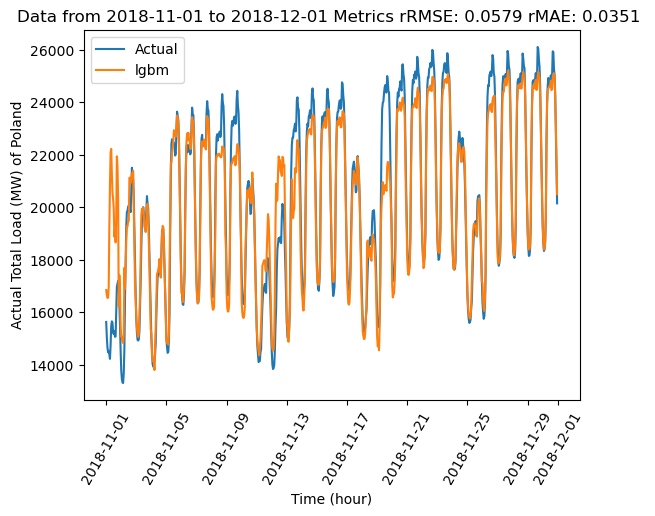

In [18]:
# plot Result dan save

plt.plot(result.index, result['consumption'], label='Actual')
plt.plot(result.index, result['prediction'],label='lgbm')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Time (hour)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of Poland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
